<a href="https://colab.research.google.com/github/JosegregTovar/GOOGLE-COLLAB/blob/main/Actividad8RLineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4029 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 8**
Regresión Lineal

---

### **Integrantes:**

*   NOMBRE: JOSEGREG DE JESUS TOVAR BLANCO
*   MATRÍCULA: A01840476
* NOMBRE: Adrian Valdes Zavala
* MATRÍCULA: A01720439
* NOMBRE: Oscar Alfonso Valenzuela Muñoz
* MATRICULA: A01840486
* NOMBRE: Sebastian Valencia Aguirre
* MATRICULA: A01364876


In [ ]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display
import math
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


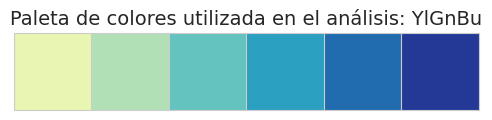

In [ ]:
# Configuración de estilo de gráficos

# Estilo general limpio
sns.set_style("whitegrid")

# Paleta oficial del ejercicio
palette = "YlGnBu"

# Configuración global de matplotlib
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Visualizamos la paleta
sns.palplot(sns.color_palette(palette))

plt.title("Paleta de colores utilizada en el análisis: YlGnBu")
plt.show()

In [ ]:
# Leer el archivo CSV
insurance_df = pd.read_csv("/content/drive/MyDrive/01 Analisis de Datos/ACTIVIDAD 8/3. DF insurance.csv")

# Mostrar las primeras filas para verificar que cargó correctamente
display(insurance_df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# DIMENSIONES DEL DATASET Y TIPOS DE DATOS

rows, cols = insurance_df.shape

print(f"El dataset contiene {rows} registros y {cols} variables. /n")

display(insurance_df.info())

El dataset contiene 1338 registros y 7 variables. /n
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


None

# **Parte 1**. EDA

Efectúa una exploración inicial de los datos a través de:

1a) Estadísticas descriptivas para todas las variables del dataframe.

In [ ]:

# ESTADÍSTICAS DESCRIPTIVAS


display(insurance_df.describe())

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


1b) Búsqueda de valores faltantes.

In [ ]:
# VALORES FALTANRES


missing_values = insurance_df.isnull().sum()

display(missing_values)

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


1c) Histrogramas y boxplots para las variables cuantitativas y diagramas de barras con la frecuencia para las variables categóricas.

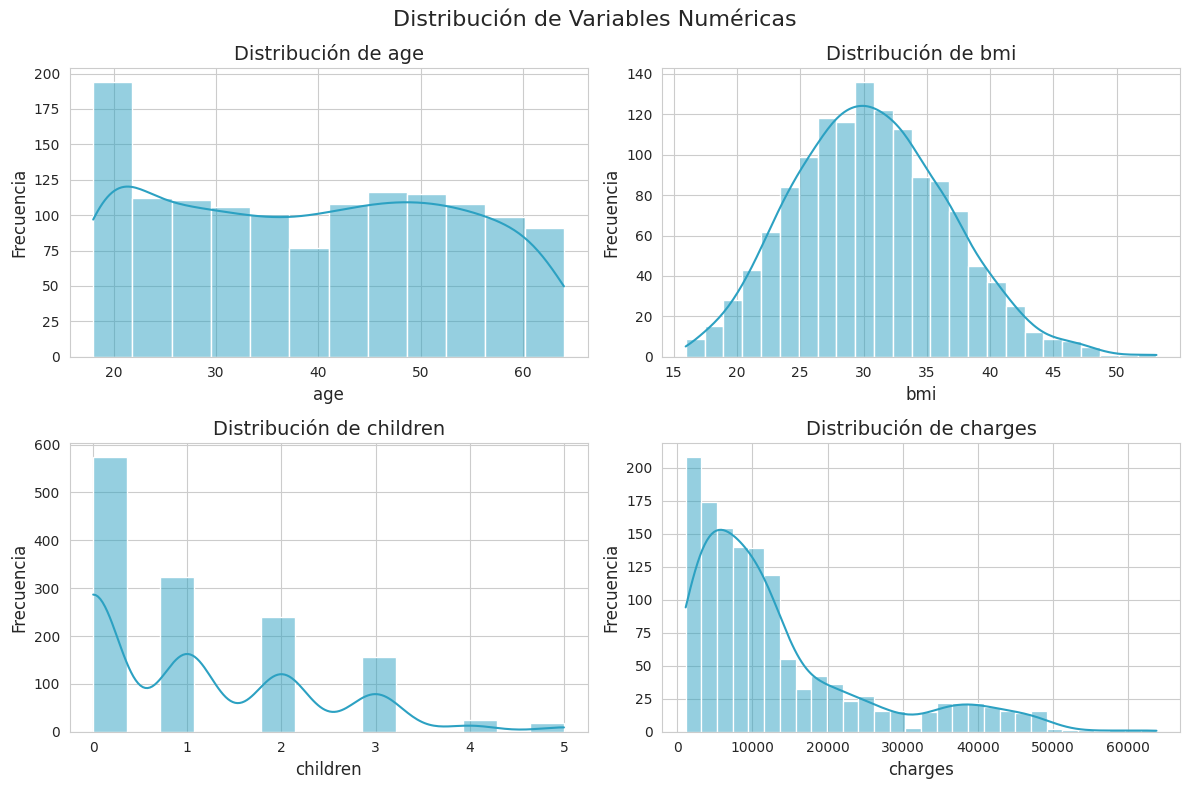

In [ ]:
# HISTOGRAMAS CON SUBPLOTS

num_cols = ['age','bmi','children','charges']

# Crear figura con una cuadrícula 2x2
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Convertimos axes en un arreglo plano para iterar facilmente
axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.histplot(
        data=insurance_df,
        x=col,
        kde=True,
        color=sns.color_palette(palette)[3],
        ax=axes[i]
    )

    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

fig.suptitle('Distribución de Variables Numéricas', fontsize=16)

# Ajustar espacios para que no se encimen los gráficos
plt.tight_layout()

plt.show()

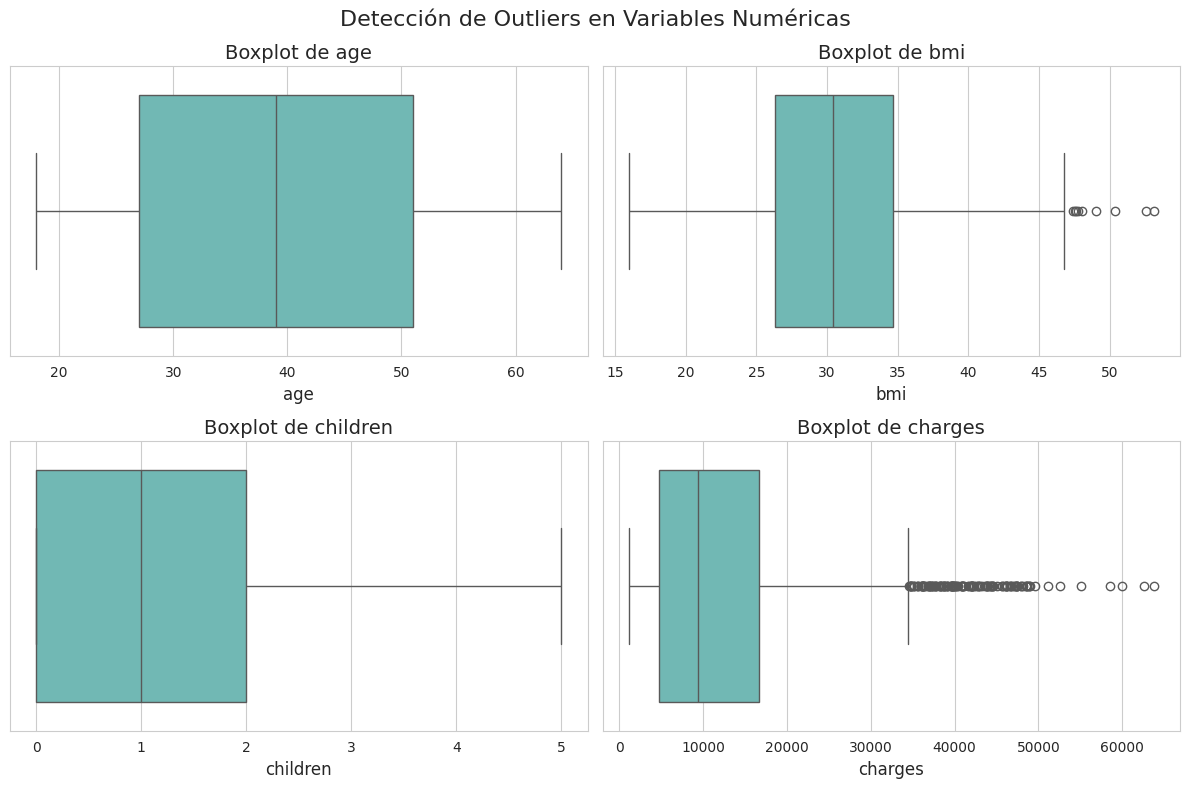

In [ ]:
# BOXPLOTS DE VARIABLES NUMERICAS EN SUBPLOTS

fig, axes = plt.subplots(2, 2, figsize=(12,8))

axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.boxplot(
        data=insurance_df,
        x=col,
        color=sns.color_palette(palette)[2],
        ax=axes[i]
    )

    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_xlabel(col)

fig.suptitle('Detección de Outliers en Variables Numéricas', fontsize=16)

plt.tight_layout()

plt.show()

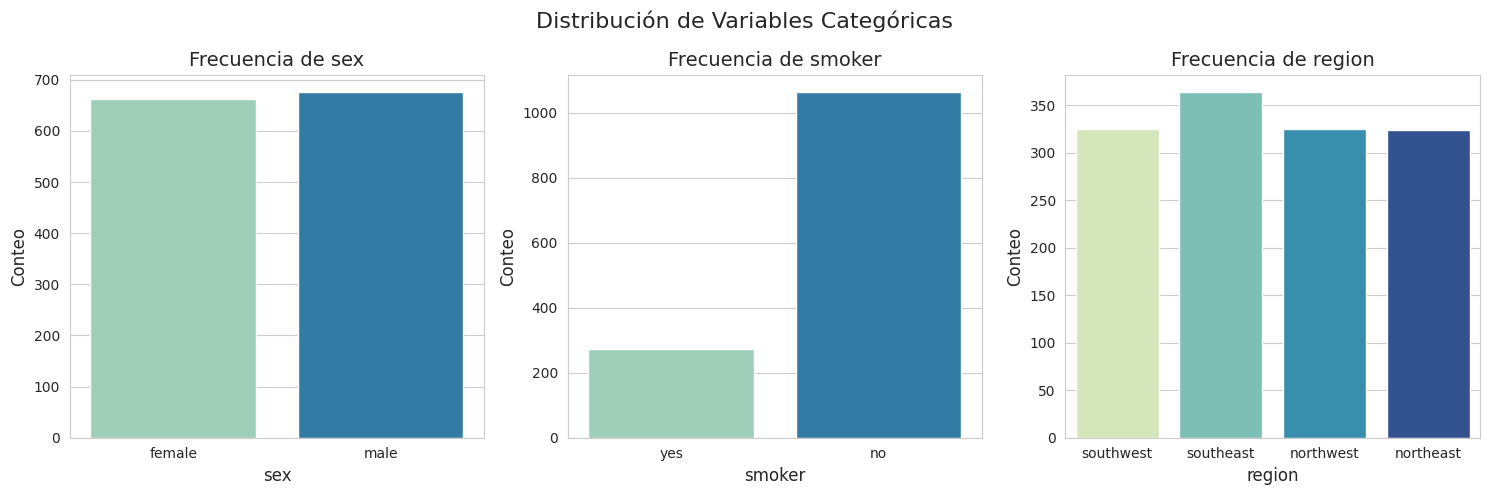

In [ ]:
# PARA VARIABLES CATEGÓRICAS


cat_cols = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, col in enumerate(cat_cols):

    sns.countplot(
        data=insurance_df,
        x=col,
        hue=col,
        legend=False,
        palette=palette,
        ax=axes[i]
    )

    axes[i].set_title(f'Frecuencia de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Conteo')

fig.suptitle('Distribución de Variables Categóricas', fontsize=16)

plt.tight_layout()

plt.show()

Para responder los siguientes cuestionamientos, genera los gráficos indicados:

2a) ¿Hay diferencias significativas de las primas según el sexo? Compara la distribución de la variable `charges` por medio de un boxplot.

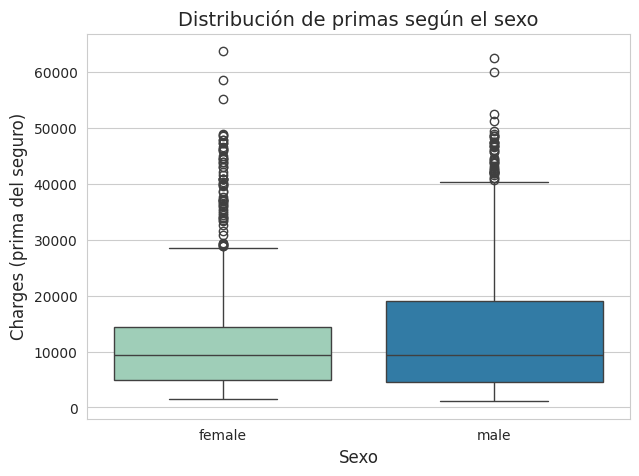

In [ ]:
# BOXPLOT: CHARGES VS SEX


plt.figure(figsize=(7,5))

sns.boxplot(
    data=insurance_df,
    x='sex',
    y='charges',
    hue='sex',
    palette=palette,
    legend=False
)

plt.title('Distribución de primas según el sexo')
plt.xlabel('Sexo')
plt.ylabel('Charges (prima del seguro)')

plt.show()

 **ANÁLISIS:**

En este dataset normalmente observamos que:

- Las medianas de charges son muy similares entre hombres y mujeres.

- No parece haber diferencias significativas por sexo.

- La dispersión es parecida.

Entonces el sexo no parece ser un predictor fuerte del costo del seguro.

2b) Crea un diagrama de dispersión de `charges` versus el `bmi` que incorpore la distinción por las categorías `smoker` y `children` (tip: utiliza el parámetro `size`) ¿Hay alguna conclusión importante que se derive del gráfico?

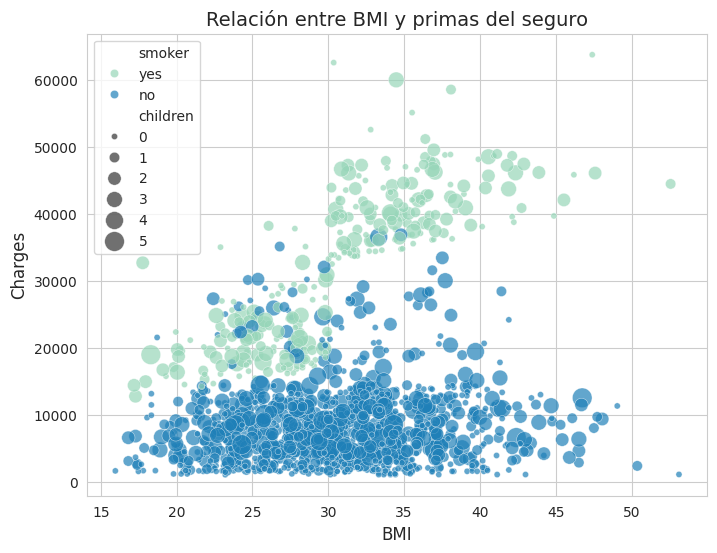

In [ ]:
# SCATTERPLOT: CHARGES VS BMI


plt.figure(figsize=(8,6))

sns.scatterplot(
    data=insurance_df,
    x='bmi',
    y='charges',
    hue='smoker',
    size='children',
    palette=palette,
    sizes=(20,200),
    alpha=0.7
)

plt.title('Relación entre BMI y primas del seguro')
plt.xlabel('BMI')
plt.ylabel('Charges')

plt.show()

**ANÁLISIS:**

Est grafica nos revela algo muy claro:

- Los fumadores tienen primas mucho más altas.
- Se forman dos grupos muy claros:
- Grupo 1: No fumadores con primas más bajas
- Grupo 2: Fumadores con primas mucho más altas

Entonces la variable smoker es probablemente uno de los factores más importantes para explicar el costo del seguro.

2c) Elabora un mapa de calor que muestre la correlación de las variables numéricas.

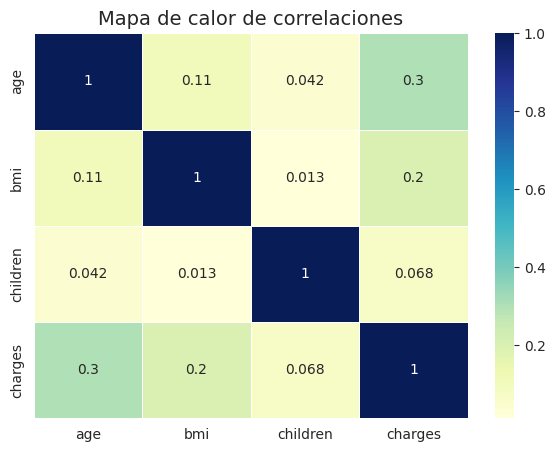

In [ ]:
# MAPA DE CALOR

# Seleccionamoss variables numericas de neuvo
num_df = insurance_df[['age','bmi','children','charges']]

# Matriz de correlación
corr_matrix = num_df.corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=palette,
    linewidths=0.5
)

plt.title('Mapa de calor de correlaciones')

plt.show()

**ANÁLISIS:**

- age tiene correlación moderada con charges

- bmi tiene una correlación moderada

- children tiene correlación débil

Pero el scatter anterior mostró que smoker tiene un efecto enorme, aunque no aparezca aquí porque es categórica.

Obtén un dataframe con las observaciones que tengan valores atípicos en `charges`.

3a) ¿Cuál es el promedio de `age` y de `bmi` en el dataframe de valores atípicos obtenido?

***Nota: Utilizaremos el metodo de IQR para detección de atípicos***

In [ ]:
# PRIMERODETECCIÓN DE OUTLIERS EN CHARGES

Q1 = insurance_df['charges'].quantile(0.25)
Q3 = insurance_df['charges'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

display(f"Q1: {Q1}")
display(f"Q3: {Q3}")
display(f"IQR: {IQR}")
display(f"Límite superior de outliers: {upper_limit}")

'Q1: 4740.28715'

'Q3: 16639.912515'

'IQR: 11899.625365'

'Límite superior de outliers: 34489.350562499996'

In [ ]:
# SEGUNDO HACEMOS UN DATAFRAME CON OBSERVACIONES ATÍPICAS

outliers_df = insurance_df[insurance_df['charges'] > upper_limit]

display(outliers_df.head())

display(f"Número de observaciones atípicas: {len(outliers_df)}")

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768
29,31,male,36.30,2,yes,southwest,38711.0000
30,22,male,35.60,0,yes,southwest,35585.5760


'Número de observaciones atípicas: 139'

In [ ]:
# PROMEDIOS DE AGE Y BMI

mean_age = outliers_df['age'].mean()
mean_bmi = outliers_df['bmi'].mean()

display(f"Edad promedio de outliers: {mean_age:.2f}")
display(f"BMI promedio de outliers: {mean_bmi:.2f}")

'Edad promedio de outliers: 41.08'

'BMI promedio de outliers: 35.56'

3b) ¿Qué porcentaje de estas observaciones (en el dataframe de valores atípicos obtenidos) se corresponden a mujeres y a hombres? ¿A fumadores y no fumadores?

In [ ]:
# PRIMERO EL PORCENTAJE POR SEXO


sex_percentage = outliers_df['sex'].value_counts(normalize=True) * 100

display(sex_percentage)

,proportion
sex,
male,64.028777
female,35.971223


In [ ]:
# AHORA PORCENTAJE DE FUMADORES


smoker_percentage = outliers_df['smoker'].value_counts(normalize=True) * 100

display(smoker_percentage)

,proportion
smoker,
yes,97.841727
no,2.158273


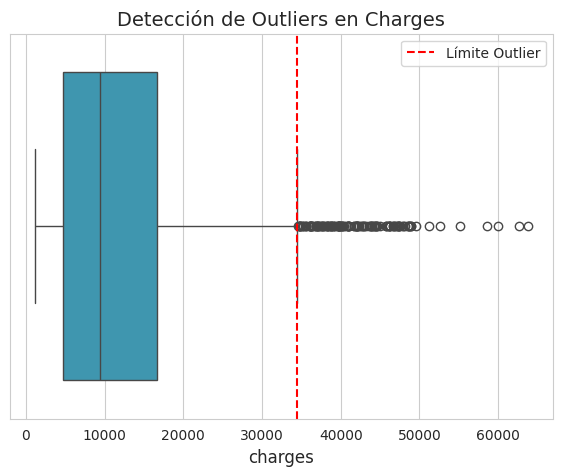

In [ ]:
# COMO SE VISUALIZAN ESTOS OUTLYERS

plt.figure(figsize=(7,5))

sns.boxplot(
    data=insurance_df,
    x='charges',
    color=sns.color_palette(palette)[3]
)

plt.axvline(upper_limit, color='red', linestyle='--', label='Límite Outlier')

plt.title('Detección de Outliers en Charges')
plt.legend()

plt.show()

**ANÁLISIS:**

Se identificaron observaciones con valores atipicos en la variable charges utilizando el método del rango IQR. Estas observaciones presentan datos considerablemente más altas que el resto del dataset. Al analizar sus características, se observa que la edad promedio y el índice de masa corporal son relativamente elevados. Ademas una gran proporción de estos registros corresponde a fumadores, lo que sugiere que el habito de fumar tiene un impacto significativo en el costo del seguro médico. Era algo de esperarse

# **Parte 2**. Preprocesamiento

4. Separa las variables del dataframe: en `X` coloca los predictores y en `y` la variable de respuesta o salida (`charges`).

In [ ]:
# SEPARAMOS VARIABLES PREDICTORAS Y OBJETIVO

# Variables predictoras
predictores = insurance_df.drop(columns='charges')

# Variable objetivo
objetivo = insurance_df['charges']

# Mostrar las primeras filas para verificar
display(predictores.head())
display(objetivo.head())

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [ ]:
# VERIFICAMOS DIMENSIONES

display(f"Dimensiones de predictores: {predictores.shape}")
display(f"Dimensiones de objetivo: {objetivo.shape}")

'Dimensiones de predictores: (1338, 6)'

'Dimensiones de objetivo: (1338,)'

In [ ]:
# IDENTIFICAMOS VARIABLES NUMÉRICAS Y CATEGÓRICAS

columnas_numericas = predictores.select_dtypes(include=['int64','float64']).columns.tolist()

columnas_categoricas = predictores.select_dtypes(include=['object']).columns.tolist()

display("Columnas numéricas:")
display(columnas_numericas)

display("Columnas categóricas:")
display(columnas_categoricas)

'Columnas numéricas:'

['age', 'bmi', 'children']

'Columnas categóricas:'

['sex', 'smoker', 'region']

5. Divide el conjunto en entrenamiento y prueba (80:20) considerando:


*   El parámetro `random_state` con el valor de 1 para garantizar reproducibilidad.
*   Analiza los diagramas de barras obtenidos en el ejercicio 1c. Con los resultados observados, es conveniente usar la variable `smoker` en la estrategia de estratificación.
*   Como ya tienes separadas en `X` e `y` los predictores y salida, consulta cómo ejecutar la función `train_test_split()` para obtener `Xtrain, Xtest, ytrain, ytest` en una única instrucción.

In [ ]:
# función para dividir datos

from sklearn.model_selection import train_test_split

# DIVISIÓN ENTRENAMIENTO Y PRUEBA

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(

    predictores,
    objetivo,

    test_size = 0.20,

    random_state = 1,

    stratify = predictores['smoker']
)

In [ ]:
# VERIFICAR DIMENSIONES


display("Dimensiones X_entrenamiento:")
display(X_entrenamiento.shape)

display("Dimensiones X_prueba:")
display(X_prueba.shape)

display("Dimensiones y_entrenamiento:")
display(y_entrenamiento.shape)

display("Dimensiones y_prueba:")
display(y_prueba.shape)

'Dimensiones X_entrenamiento:'

(1070, 6)

'Dimensiones X_prueba:'

(268, 6)

'Dimensiones y_entrenamiento:'

(1070,)

'Dimensiones y_prueba:'

(268,)

In [ ]:
# VERIFICAR SI SE MANTUVO LA PROPORCION

display("Distribución en dataset original")
display(predictores['smoker'].value_counts(normalize=True))

display("Distribución en entrenamiento")
display(X_entrenamiento['smoker'].value_counts(normalize=True))

display("Distribución en prueba")
display(X_prueba['smoker'].value_counts(normalize=True))

'Distribución en dataset original'

,proportion
smoker,
no,0.795217
yes,0.204783


'Distribución en entrenamiento'

,proportion
smoker,
no,0.795327
yes,0.204673


'Distribución en prueba'

,proportion
smoker,
no,0.794776
yes,0.205224


6. Prepara un transformador, denominado `preprocessing`, para aplicar escalamiento *MinMax* a los predictores numéricos y codificación *one-hot* a los categóricas.

In [ ]:
# TRANSFORMADOR DE PREPROCESAMIENTO

preprocesamiento = ColumnTransformer(
    transformers = [
        ('numericas', MinMaxScaler(), columnas_numericas),
        ('categoricas', OneHotEncoder(drop='first', handle_unknown='ignore'), columnas_categoricas)
    ]
)

display(preprocesamiento)

ColumnTransformer(transformers=[('numericas', MinMaxScaler(),
                                 ['age', 'bmi', 'children']),
                                ('categoricas',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])

In [ ]:
# PRUEBA DEL TRANSFORMADOR

X_entrenamiento_transformado = preprocesamiento.fit_transform(X_entrenamiento)

display("Forma de X_entrenamiento original:")
display(X_entrenamiento.shape)

display("Forma de X_entrenamiento transformado:")
display(X_entrenamiento_transformado.shape)


'Forma de X_entrenamiento original:'

(1070, 6)

'Forma de X_entrenamiento transformado:'

(1070, 8)

In [ ]:
# VER COMO QUEDA EL DATAFRAME TRANSFORMADO
# (NO ME GUSTA IR A CIEGAS)
columnas_transformadas = preprocesamiento.get_feature_names_out()
df_entrenamiento_transformado = pd.DataFrame(
    X_entrenamiento_transformado,
    columns=columnas_transformadas
)

display(df_entrenamiento_transformado.head())

,numericas__age,numericas__bmi,numericas__children,categoricas__sex_male,categoricas__smoker_yes,categoricas__region_northwest,categoricas__region_southeast,categoricas__region_southwest
0,0.500000,0.136720,0.2,1.0,0.0,0.0,1.0,0.0
1,0.108696,0.924274,0.2,1.0,0.0,0.0,1.0,0.0
2,0.239130,0.253752,0.0,0.0,0.0,1.0,0.0,0.0
3,0.608696,0.426408,0.4,0.0,0.0,0.0,0.0,0.0
4,0.413043,0.475974,0.8,1.0,1.0,0.0,0.0,1.0


# **Parte 3**. Entrenando y evaluando el modelo de RL

7. Ejecuta un pipeline con el transformador creado y el algoritmo de regresión lineal para entrenar un modelo denominado `lr_model`.

Evalúa el modelo en el conjunto de prueba y obtén la raíz del error cuadrático medio (`RMSE`) y la métrica `R` cuadrado ($R^2$). Aunque ésta última la estudiarás a detalle la próxima semana, ahora sólo debes saber que toma valores entre 0 y 1, donde 1 indica un ajuste perfecto y, por tanto, un modelo muy fiable para las previsiones futuras. La función de scikit-learn que determina esta métrica es: [`r2_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

In [ ]:
# PIPELINE DE REGRESION LINEAL

modelo_rl = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento),
    ('regresion_lineal', LinearRegression())
])

display(modelo_rl)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas', MinMaxScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('categoricas',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regresion_lineal', LinearRegression())])

In [ ]:
# ENTRENAMIENTO DEL MODELO


modelo_rl.fit(X_entrenamiento, y_entrenamiento)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas', MinMaxScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('categoricas',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regresion_lineal', LinearRegression())])

In [ ]:
# PREDICCIONES EN EL CONJUNTO DE PRUEBA

predicciones_prueba = modelo_rl.predict(X_prueba)

display(predicciones_prueba[:10])

array([11372.80813784, 27856.47143324,  9733.36589604, 18149.77573544,
        4115.25076074,  6439.18800356,  5842.83840001, 11254.23349345,
        1285.0475368 ,  9157.83835383])

In [ ]:
# EVALUACIÓN DEL MODELO

# Error cuadrático medio
mse_modelo = mean_squared_error(
    y_prueba,
    predicciones_prueba
)

# Raíz del error cuadrático medio
rmse_modelo = np.sqrt(mse_modelo)

# Coeficiente de determinación
r2_modelo = r2_score(
    y_prueba,
    predicciones_prueba
)

display(f'RMSE del modelo: {rmse_modelo:.2f}')
display(f'R² del modelo: {r2_modelo:.4f}')

'RMSE del modelo: 5698.76'

'R² del modelo: 0.7539'

**ANÁLISIS:**

El valor obtenido fue R2 = 0.7539, lo que significa que el modelo de regresión lineal logra explicar aproximadamente el 75.39% de la variabilidad en los costos del seguro a partir de las variables predictoras incluidas en el modelo. Esto indica que el modelo presenta un ajuste medianamente razonable, ya que todavia existe una parte de la variabilidad que no es explicada por el modelo y que puede estar asociada a otros factores o a la presencia de valores atípicos en la variable charges

**Valora el rendimiento del modelo con los siguientes cambios:**


8. Reemplaza los outliers de `charges` con el límite superior (`Q3 + 1.5 * IQR`) que obtuviste en la pregunta 3a. Haz el cambio en ambos conjuntos: `ytrain` y `ytest`, previo a la aplicación del mismo pipeline. Guarda el modelo como `lr_model2`.


In [ ]:
# HACEMOS COPIAS DE LA VARIABLE OBJETIVO


objetivo_entrenamiento_ajustado = y_entrenamiento.copy()
objetivo_prueba_ajustado = y_prueba.copy()

# Reemplazamos outliers

objetivo_entrenamiento_ajustado = objetivo_entrenamiento_ajustado.clip(upper=upper_limit)
objetivo_prueba_ajustado = objetivo_prueba_ajustado.clip(upper=upper_limit)

# verificamos el cambio con el ajuste

display("Valor maximo original en y_entrenamiento:")
display(y_entrenamiento.max())

display("Valor maximo ajustado en y_entrenamiento:")
display(objetivo_entrenamiento_ajustado.max())

display("Valor maximo original en y_prueba:")
display(y_prueba.max())

display("Valor maximo ajustado en y_prueba:")
display(objetivo_prueba_ajustado.max())

'Valor maximo original en y_entrenamiento:'

63770.42801

'Valor maximo ajustado en y_entrenamiento:'

34489.350562499996

'Valor maximo original en y_prueba:'

48675.5177

'Valor maximo ajustado en y_prueba:'

34489.350562499996

In [ ]:
# SEGUNDO MODELO DE REGRESION LINEAL

# (corresponde a lr_model2)

modelo_rl_2 = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento),
    ('regresion_lineal', LinearRegression())
])

display(modelo_rl_2)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas', MinMaxScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('categoricas',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regresion_lineal', LinearRegression())])

In [ ]:
# ENTRENAR EL SEGUNDO MODELO

modelo_rl_2.fit(X_entrenamiento, objetivo_entrenamiento_ajustado)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas', MinMaxScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('categoricas',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regresion_lineal', LinearRegression())])

In [ ]:
# PREDICCIONES DEL 2DO MODELO

predicciones_prueba_2 = modelo_rl_2.predict(X_prueba)

display(predicciones_prueba_2[:10])

array([11675.38021151, 24815.34395614, 10196.80808021, 16422.50957323,
        5053.32798522,  6516.17909531,  6350.42717049, 10942.09671377,
        3233.77981141,  9363.06633299])

In [ ]:
# EVALUACIÓN DEL 2DO MODELO

mse_modelo_2 = mean_squared_error(
    objetivo_prueba_ajustado,
    predicciones_prueba_2
)

rmse_modelo_2 = np.sqrt(mse_modelo_2)

r2_modelo_2 = r2_score(
    objetivo_prueba_ajustado,
    predicciones_prueba_2
)

display(f'RMSE del modelo 2: {rmse_modelo_2:.2f}')
display(f'R² del modelo 2: {r2_modelo_2:.4f}')

'RMSE del modelo 2: 4812.06'

'R² del modelo 2: 0.7638'

In [ ]:
# COMPARACIÓN DE RESULTADOS


comparacion_metricas = pd.DataFrame({
    'modelo': ['Modelo original', 'Modelo con outliers ajustados'],
    'RMSE': [rmse_modelo, rmse_modelo_2],
    'R²': [r2_modelo, r2_modelo_2]
})

display(comparacion_metricas)

,modelo,RMSE,R²
0,Modelo original,5698.759785,0.753855
1,Modelo con outliers ajustados,4812.061728,0.763778


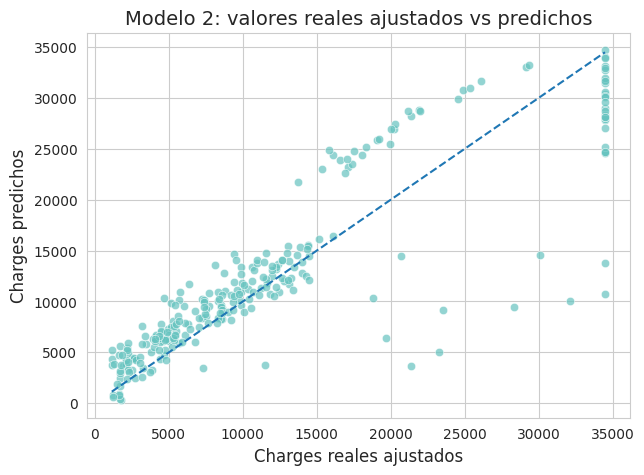

In [ ]:
# COMPARACIÓN VISUAL REAL VS PREDICHO

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=objetivo_prueba_ajustado,
    y=predicciones_prueba_2,
    color=sns.color_palette(palette)[2],
    alpha=0.7
)

plt.plot(
    [objetivo_prueba_ajustado.min(), objetivo_prueba_ajustado.max()],
    [objetivo_prueba_ajustado.min(), objetivo_prueba_ajustado.max()],
    linestyle='--'
)

plt.title('Modelo 2: valores reales ajustados vs predichos')
plt.xlabel('Charges reales ajustados')
plt.ylabel('Charges predichos')

plt.show()

**ANÁLISIS:**

Después de reemplazar los valores atípicos de la variable charges por el límite superior calculado mediante la regla (Q3 + 1.5 \times IQR), se volvio a entrenar el modelo de regresión lineal. El coeficiente de determinación pasó de **0.7539** a **0.7638**, lo que representa una mejora bien ligera en la capacidad del modelo.

Este cambio moderado sugiere que los valores extremos presentes en la variable charges no corresponden necesariamente a errores en los datos, sino que probablemente reflejan casos reales de primas altas asociados a factores como el habito de fumar o valores elevados de BMI. Por lo tanto, aunque el ajuste de outliers reduce ligeramente el error del modelo.


9. Prepara otro transformador, denominado `preprocessing2`, para aplicar escalamiento estándar a los predictores numéricos y codificación ordinal a los categóricas. Aplícalo en un nuevo pipeline utilizando nuevamente regresión lineal. Guarda el modelo como `lr_model3`.

**Nota.** Los cambios se ejecutan de manera consecutiva, por ejemplo: el reemplazo de los outliers también se ejecuta previo al transformador `preprocessing2` y así sucesivamente.

In [ ]:
# TRANSFORMADOR DE PREPROCESAMIENTO 2

preprocesamiento2 = ColumnTransformer(
    transformers=[
        ('numericas', StandardScaler(), columnas_numericas),
        ('categoricas', OrdinalEncoder(), columnas_categoricas)
    ]
)

display(preprocesamiento2)

ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                 ['age', 'bmi', 'children']),
                                ('categoricas', OrdinalEncoder(),
                                 ['sex', 'smoker', 'region'])])

In [ ]:
# PIPELINE DEL MODELO 3
# (corresponde a lr_model3)

modelo_rl_3 = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento2),
    ('regresion_lineal', LinearRegression())
])

display(modelo_rl_3)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('categoricas',
                                                  OrdinalEncoder(),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regresion_lineal', LinearRegression())])

In [ ]:
# ENTRENAMIENTO DEL MODELO 3


modelo_rl_3.fit(X_entrenamiento, objetivo_entrenamiento_ajustado)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('categoricas',
                                                  OrdinalEncoder(),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regresion_lineal', LinearRegression())])

In [ ]:
# PREDICCIONES
predicciones_prueba_3 = modelo_rl_3.predict(X_prueba)

display(predicciones_prueba_3[:10])

array([11756.14163712, 24766.74622886, 10275.00328422, 16545.09886815,
        5209.06344336,  6473.59611434,  6498.38997621, 10795.67858251,
        3334.77731449,  9346.76313188])

In [ ]:
# EVALUACIÓN DEL MODELO 3

mse_modelo_3 = mean_squared_error(
    objetivo_prueba_ajustado,
    predicciones_prueba_3
)

rmse_modelo_3 = np.sqrt(mse_modelo_3)

r2_modelo_3 = r2_score(
    objetivo_prueba_ajustado,
    predicciones_prueba_3
)

display(f'RMSE del modelo 3: {rmse_modelo_3:.2f}')
display(f'R² del modelo 3: {r2_modelo_3:.4f}')

'RMSE del modelo 3: 4811.60'

'R² del modelo 3: 0.7638'

In [ ]:
# COMPARAR PARA VER QUE MODELO ES MEJOR

comparacion_modelos = pd.DataFrame({
    'modelo': [
        'Modelo base',
        'Modelo con outliers ajustados',
        'Modelo con StandardScaler + OrdinalEncoder'
    ],

    'RMSE': [
        rmse_modelo,
        rmse_modelo_2,
        rmse_modelo_3
    ],

    'R²': [
        r2_modelo,
        r2_modelo_2,
        r2_modelo_3
    ]
})

display(comparacion_modelos)

,modelo,RMSE,R²
0,Modelo base,5698.759785,0.753855
1,Modelo con outliers ajustados,4812.061728,0.763778
2,Modelo con StandardScaler + OrdinalEncoder,4811.600670,0.763823


**ANÁLISIS**

Al aplicar StandardScaler y OrdinalEncoder, el modelo alcanzó un RMSE de 4811.60 y un R² de 0.7638, mostrando una mejora mínima. En general, los resultados indican que la mayor mejora proviene del tratamiento de los valores atípicos, mientras que los cambios en el preprocesamiento tienen un impacto marginal en el desempeño del modelo.

10. Utiliza regresión polinomial para verificar si se produce un mejor ajuste. Intenta con varios grados, aunque debes dejar en el código sólo el de mejor rendimiento. Guarda el modelo como `lr_model4`.

In [ ]:
# BUSCAMOS EL MEJOR GRADO POLINOMIAL

resultados_grados = []

for grado in [2, 3, 4, 5]:

    # Crear pipeline para cada grado
    modelo_polinomial = Pipeline(steps=[
        ('preprocesamiento', preprocesamiento2),
        ('polinomios', PolynomialFeatures(degree=grado, include_bias=False)),
        ('regresion_lineal', LinearRegression())
    ])

    # Entrenar modelo
    modelo_polinomial.fit(X_entrenamiento, objetivo_entrenamiento_ajustado)

    # Predecir en prueba
    predicciones_prueba_pol = modelo_polinomial.predict(X_prueba)

    # Calcular métricas
    mse_pol = mean_squared_error(
        objetivo_prueba_ajustado,
        predicciones_prueba_pol
    )

    rmse_pol = np.sqrt(mse_pol)

    r2_pol = r2_score(
        objetivo_prueba_ajustado,
        predicciones_prueba_pol
    )

    # Guardar resultados
    resultados_grados.append({
        'grado': grado,
        'RMSE': rmse_pol,
        'R²': r2_pol
    })

# Convertir resultados a DataFrame
resultados_grados_df = pd.DataFrame(resultados_grados)

display(resultados_grados_df.sort_values(by='R²', ascending=False))

,grado,RMSE,R²
0,2,4285.570311,0.812640
1,3,4377.170155,0.804546
2,4,4821.877852,0.762813
3,5,7789.244197,0.381059


Entonces nos queda asi:

In [ ]:
# (corresponde a lr_model4)

modelo_rl_4 = Pipeline(steps=[

    ('preprocesamiento', preprocesamiento2),

    ('polinomios', PolynomialFeatures(degree=2, include_bias=False)), #el mejor grado fue el 2

    ('regresion_lineal', LinearRegression())
])

display(modelo_rl_4)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('categoricas',
                                                  OrdinalEncoder(),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('polinomios', PolynomialFeatures(include_bias=False)),
                ('regresion_lineal', LinearRegression())])

In [ ]:
# ENTRENAMOS MODELO

modelo_rl_4.fit(X_entrenamiento, objetivo_entrenamiento_ajustado)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('categoricas',
                                                  OrdinalEncoder(),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('polinomios', PolynomialFeatures(include_bias=False)),
                ('regresion_lineal', LinearRegression())])

In [ ]:
# GENERAMOS PREDICCIONES DEL MODELO POLINOMIAL

predicciones_prueba_4 = modelo_rl_4.predict(X_prueba)

display(predicciones_prueba_4[:10])

array([14330.80456117, 21405.46247871, 11342.57417438, 17079.54840129,
        4868.3554282 ,  5539.76647332,  6394.98804931, 11475.61806481,
        4768.26076811,  9525.11580925])

In [ ]:
# EVALUAMOS EL MODELO POLINOMIAL

mse_modelo_4 = mean_squared_error(
    objetivo_prueba_ajustado,
    predicciones_prueba_4
)

rmse_modelo_4 = np.sqrt(mse_modelo_4)

r2_modelo_4 = r2_score(
    objetivo_prueba_ajustado,
    predicciones_prueba_4
)

display(f'RMSE del modelo 4: {rmse_modelo_4:.2f}')
display(f'R² del modelo 4: {r2_modelo_4:.4f}')

'RMSE del modelo 4: 4285.57'

'R² del modelo 4: 0.8126'

In [ ]:
# COMPARACIÓN FINAL DE TODOS LOS MODELOS


comparacion_modelos = pd.DataFrame({
    'modelo': [
        'Modelo base',
        'Modelo con outliers ajustados',
        'Modelo con StandardScaler + OrdinalEncoder',
        'Modelo polinomial'
    ],

    'RMSE': [
        rmse_modelo,
        rmse_modelo_2,
        rmse_modelo_3,
        rmse_modelo_4
    ],

    'R²': [
        r2_modelo,
        r2_modelo_2,
        r2_modelo_3,
        r2_modelo_4
    ]
})

display(comparacion_modelos)

,modelo,RMSE,R²
0,Modelo base,5698.759785,0.753855
1,Modelo con outliers ajustados,4812.061728,0.763778
2,Modelo con StandardScaler + OrdinalEncoder,4811.600670,0.763823
3,Modelo polinomial,4285.570311,0.812640


**ANÁLISIS:**

Se evaluaron distintos grados en la regresión polinomial con el fin de identificar la configuración con mejor desempeño en el conjunto de prueba. Para cada grado se calcularon las métricas RMSE y R2 y posteriormente se seleccionó el modelo con mejor capacidad explicativa y menor error de predicción que fue el de grado 2. Este procedimiento permitió verificar que la incorporación de relaciones no lineales mejora el ajuste respecto a los modelos lineales anteriores.

Al comparar los resultados obtenidos, se observa una mejora progresiva en el desempeño del modelo. El **modelo base** alcanzó un RMSE de **5698.76** y un **R2 de 0.7539**, mientras que el ajuste de valores atipicos redujo el error a **4812.06** y elevó el R2 a **0.7638**. El cambio en la estrategia de preprocesamiento con StandardScaler + OrdinalEncoder produjo una mejora mínima (R2 = **0.7638**). Sin embargo, al aplicar regresión polinomial el modelo logró capturar relaciones no lineales entre las variables, reduciendo el RMSE a **4285.57** y aumentando el **R2 a 0.8126**, lo que indica que el modelo ahora explica aproximadamente **81.26% de la variabilidad en los costos del seguro**. Esto confirma que la inclusión de terminos polinomiales permite representar mejor las relaciones entre las variables predictoras y la prima del seguro.
